In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
from PIL import Image
import pydicom
from scipy.ndimage import median_filter
from skimage import measure, morphology


In [2]:
def load_npy(file_path: str):
    return np.load(file_path)

def load_npz(file_path: str):
    data = np.load(file_path)
    return data

def load_pickle(file_path: str):
    with open(file_path, "rb") as f:
        data = pickle.load(f) 
    return data

def load_dcom(file_path: str):
    return pydicom.dcmread(file_path)

def scale_image(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val - min_val == 0:
        return np.zeros_like(image, dtype=np.uint8)
    
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    
    return scaled_image.astype(np.uint8)

def normalize_image(image):
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val - min_val > 0:
        image = (image - min_val) / (max_val - min_val)

    return image

def lung_window_clip(array: np.ndarray, min_px: int = -1000, max_px: int = 400):
    clipped_array = array.copy()
    clipped_array[clipped_array > max_px] = max_px
    clipped_array[clipped_array < min_px] = min_px
    return clipped_array

def plot_images(array_HU, array_Lung, title1="HU", title2="Lung"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(array_HU, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis("off")  # Hide axis

    axes[1].imshow(array_Lung, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis("off")  # Hide axis

def numpy_to_gif(image_array, mask_array, lung_array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exist_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}.gif"

    print(save_path_x)
    frames = []
    
    for i in range(image_array.shape[0]):
        img = Image.fromarray(scale_image(image_array[i, :, :]))
        lung = Image.fromarray(scale_image(lung_array[i, :, :]))
        mask = Image.fromarray(scale_image(mask_array[i, :, :]))
        
        combined = Image.new("L", (img.width * 3, img.height))
        combined.paste(img, (0, 0))
        combined.paste(mask, (mask.width, 0))
        combined.paste(lung, (lung.width * 2, 0))
        
        frames.append(combined)
        
    frames[0].save(save_path_x, save_all=True, append_images=frames[1:], duration=duration, loop=0)

def lung_window_clip_volume(pixel_array: np.ndarray, min_px: int = -1000, max_px: int = 400):
    clipped_array = []
    for arr in pixel_array:
        clipped = arr.copy()
        clipped[clipped > max_px] = max_px
        clipped[clipped < min_px] = min_px
        clipped_array.append(clipped)
        
    return np.stack(clipped_array, axis = 0)

def numpy_to_gif_1_sample(array, folder_path="/data/hpc/dqm/3D-SegClass-Medical/assets", folder_name: str = "image", case_name: str = "3", duration=100):
    folder_path = folder_path + "/" + folder_name
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path, exists_ok=True)
        
    save_path_x = f"{folder_path}/{case_name}.gif"
    print(save_path_x)
    frames_x = []

    
    for i in range(array.shape[0]):
        img_x = Image.fromarray(scale_image(array[i, :, :])) 
        frames_x.append(img_x)

    frames_x[0].save(save_path_x, save_all=True, append_images=frames_x[1:], duration=duration, loop=0)


In [5]:
test = load_npy("/mnt/nvme1n1/duong.quang.minh/data/Image/LIDC-IDRI-0001/0001_NI001.npy")
test.shape

(188, 360, 360)

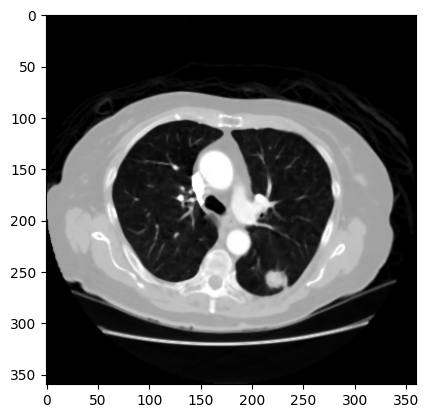

In [23]:
plt.imshow(test[101, :, :], cmap="gray")


In [3]:
mask = load_npy("/mnt/nvme1n1/duong.quang.minh/data/Mask/LIDC-IDRI-0001/0001_MA001.npy")
mask.shape

(188, 360, 360)

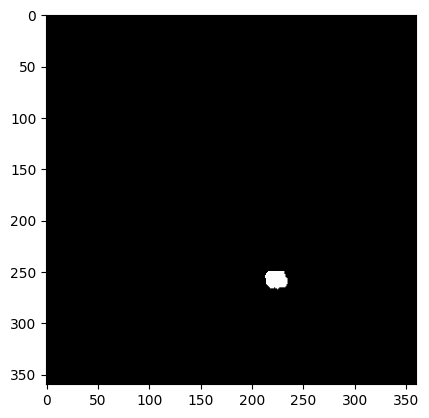

In [26]:
plt.imshow(mask[101, :, :], cmap="gray")

In [27]:
import cv2
cv2.imwrite("Mask.png", mask[101, :, :].astype(np.uint8) * 255)


True

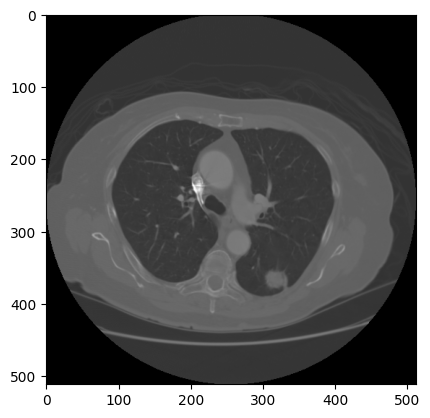

In [73]:
plt.imshow(test[92, :, :], cmap="gray")

In [75]:
import cv2

save_img = test[92, :, :]
save_img = lung_window_clip(save_img)
print(save_img.max())
print(save_img.min())
save_img = scale_image(save_img)

cv2.imwrite("Clipped.png", save_img)

400
-1000


True

In [4]:
def normalize_clipped(image, MIN_BOUND = -1000.0, MAX_BOUND = 400.0):
    image[image>MAX_BOUND] = MAX_BOUND
    image[image<MIN_BOUND] = MIN_BOUND
    return image

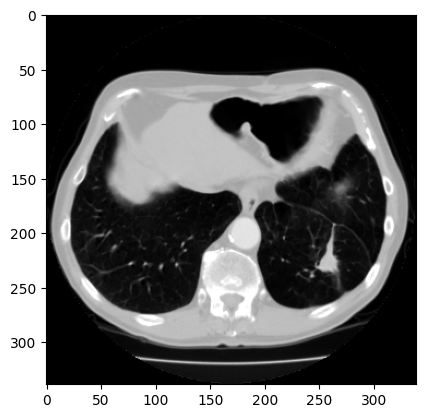

In [5]:
plt.imshow(normalize_clipped(test[99, :, :]), cmap="gray")

In [6]:
def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None
def segment_lung_mask(image, fill_lung_structures=True, threshhold: int = -320): # include structures within the lung
    
    binary_image = np.array(image > threshhold, dtype=np.int8) + 1
    labels = measure.label(binary_image, connectivity=3)
    
    background_label = labels[0,0,0]
    #Fill the air around the person
    binary_image[background_label == labels] = 2

    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1
    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1

    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0

    return binary_image

In [7]:
b = segment_lung_mask(normalize_clipped(test), threshhold=-320, fill_lung_structures=True)

In [201]:
b, l = segment_lung_mask(normalize_clipped(test), threshhold=-320, fill_lung_structures=True)

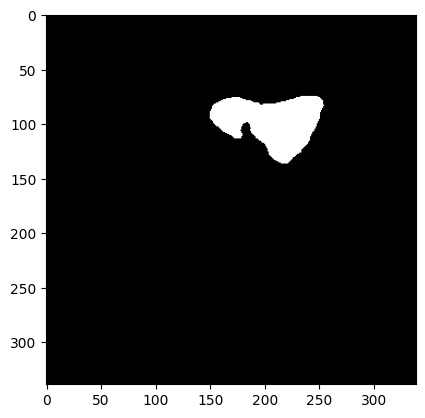

In [9]:
plt.imshow(b[99, :, :], cmap="gray")


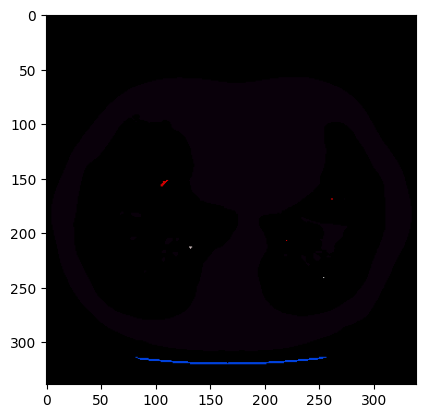

In [206]:
plt.imshow(labels[130, :, :], cmap='nipy_spectral')


In [209]:
background_label = l[0,0,0]
background_label

1

In [210]:
b[background_label == l] = 2
b

array([[[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       ...,

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [2, 2, 2, ..., 

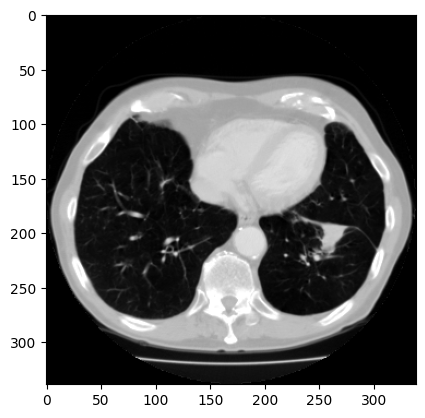

In [187]:
plt.imshow(test[130, :, :], cmap="gray")

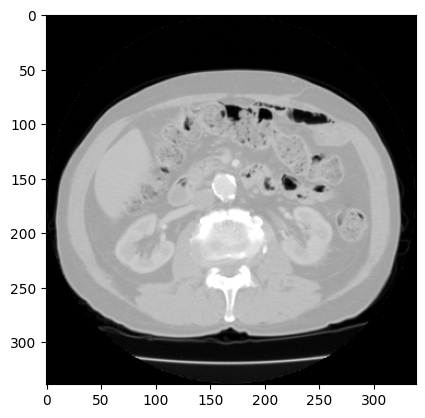

In [190]:
plt.imshow(test[0, :, :], cmap="gray")

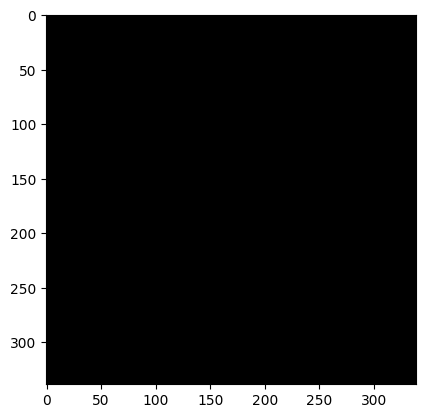

In [146]:
plt.imshow(b[130, :, :], cmap="gray")


In [147]:
numpy_to_gif_1_sample(b * 255, folder_name="vis", case_name="395_aaa")

/data/hpc/dqm/3D-SegClass-Medical/assets/vis/395_aaa.gif


In [8]:
lst = [i for i in range(1, 1012)]
lst = [f"{i:04d}" for i in lst]

In [9]:
lst

['0001',
 '0002',
 '0003',
 '0004',
 '0005',
 '0006',
 '0007',
 '0008',
 '0009',
 '0010',
 '0011',
 '0012',
 '0013',
 '0014',
 '0015',
 '0016',
 '0017',
 '0018',
 '0019',
 '0020',
 '0021',
 '0022',
 '0023',
 '0024',
 '0025',
 '0026',
 '0027',
 '0028',
 '0029',
 '0030',
 '0031',
 '0032',
 '0033',
 '0034',
 '0035',
 '0036',
 '0037',
 '0038',
 '0039',
 '0040',
 '0041',
 '0042',
 '0043',
 '0044',
 '0045',
 '0046',
 '0047',
 '0048',
 '0049',
 '0050',
 '0051',
 '0052',
 '0053',
 '0054',
 '0055',
 '0056',
 '0057',
 '0058',
 '0059',
 '0060',
 '0061',
 '0062',
 '0063',
 '0064',
 '0065',
 '0066',
 '0067',
 '0068',
 '0069',
 '0070',
 '0071',
 '0072',
 '0073',
 '0074',
 '0075',
 '0076',
 '0077',
 '0078',
 '0079',
 '0080',
 '0081',
 '0082',
 '0083',
 '0084',
 '0085',
 '0086',
 '0087',
 '0088',
 '0089',
 '0090',
 '0091',
 '0092',
 '0093',
 '0094',
 '0095',
 '0096',
 '0097',
 '0098',
 '0099',
 '0100',
 '0101',
 '0102',
 '0103',
 '0104',
 '0105',
 '0106',
 '0107',
 '0108',
 '0109',
 '0110',
 '0111',
 

In [13]:
for case in lst:
    try:
        mask = load_npy(f"/mnt/nvme1n1/duong.quang.minh/data/Mask/LIDC-IDRI-{case}/{case}_MA001.npy")
    except FileNotFoundError:
        try:
            mask = load_npy(f"/mnt/nvme1n1/duong.quang.minh/data/Clean/Mask/LIDC-IDRI-{case}/{case}_CM001.npy")
            print(mask.shape)
        except Exception as e:
            print(case)


(352, 340, 340)
(311, 493, 493)
0035
(292, 360, 360)
(326, 466, 466)
0074


(336, 449, 449)
0114
(332, 340, 340)
(332, 380, 380)
(292, 340, 340)
(318, 400, 400)
(338, 380, 380)
(378, 440, 440)
0218
(332, 420, 420)
(332, 400, 400)
(308, 460, 460)
0238
(382, 380, 380)
(332, 400, 400)
(348, 400, 400)
(322, 380, 380)
(605, 310, 310)
(355, 320, 320)
(308, 316, 316)
(330, 320, 320)
(402, 370, 370)
(320, 360, 360)
(636, 360, 360)
(268, 272, 272)
(301, 283, 283)
(329, 300, 300)
(322, 357, 357)
(315, 340, 340)
(358, 310, 310)
0361
(302, 371, 371)
(318, 311, 311)
(295, 400, 400)
(339, 367, 367)
(348, 400, 400)
(332, 390, 390)
(315, 340, 340)
(300, 345, 345)
(282, 489, 489)
(322, 360, 360)
(380, 320, 320)
(326, 280, 280)
(409, 275, 275)
(345, 387, 387)
0447
(280, 360, 360)
(350, 370, 370)
(290, 332, 332)
0479
(312, 312, 312)
(382, 380, 380)
(300, 330, 330)
(330, 340, 340)
(351, 276, 276)
(355, 320, 320)
(305, 316, 316)
0523
(315, 354, 354)
(308, 301, 301)
(596, 400, 400)
(326, 300, 300)
(300, 285, 285)
(345, 365, 365)
(392, 340, 340)
(596, 440, 440)
(318, 330, 330)
0585


In [30]:
lst = [447, 479, 671, 894]
lst = [f"{i:04d}" for i in lst]
lst

['0447', '0479', '0671', '0894']

In [13]:
for case in ["0430", "0664", "0790", "0365"]:
    image = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Image/LIDC-IDRI-{case}/{case}_NI001.npy")
    lung = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Lung_Segmentation_v2/LIDC-IDRI-{case}/{case}_NI001.npy")
    mask = load_npy(f"/data/hpc/dqm/3D-SegClass-Medical/data/Mask/LIDC-IDRI-{case}/{case}_MA001.npy")

    print(image.shape)
    print(lung.shape)
    print(mask.shape)

    numpy_to_gif(image, mask * 255, lung, case_name=f"{case}_v3", folder_name="test")

(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0430_v3.gif


(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0664_v3.gif
(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0790_v3.gif
(188, 256, 256)
(188, 256, 256)
(188, 256, 256)
/data/hpc/dqm/3D-SegClass-Medical/assets/test/0365_v3.gif


In [10]:
lung.min()

-1.1546316

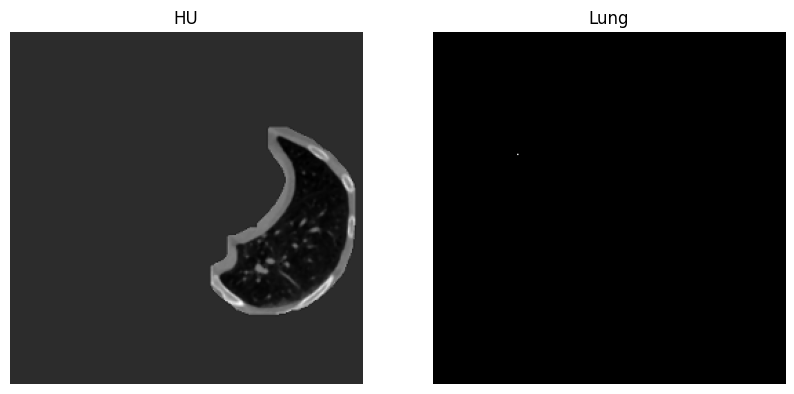

In [6]:
plot_images(lung[50, :, :], mask[90, :, :] * 255)

In [61]:
def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None
    
def denormalize_clipped(image, MIN_BOUND=-1000.0, MAX_BOUND=400.0):
    image = image * (MAX_BOUND - MIN_BOUND) + MIN_BOUND
    return image

def segment_lung_mask(image, fill_lung_structures=True): # include structures within the lung
    
    # not actually binary, but 1 and 2. 
    # 0 is treated as background, which we do not want
    binary_image = np.array(image > -320, dtype=np.int8)+1
    labels = measure.label(binary_image)

    background_label = labels[0,0,0]
    
    #Fill the air around the person
    binary_image[background_label == labels] = 2
    
    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1
    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1
    
    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0
 
    return binary_image.astype(np.float32)

In [22]:
def make_lungmask_version_2(img):
    
    image_original = img.copy()
    
    row_size = img.shape[0]
    col_size = img.shape[1]

    mean = np.mean(img)
    std = np.std(img)
    img = img - mean
    img = img / std
    
    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)
    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img == max] = mean
    img[img == min] = mean
    
    # apply median filter
    img = median_filter(img,size=3)
    #apply anistropic non-linear diffusion filter- This removes noise without blurring the nodule boundary
    img = anisotropic_diffusion(img)
    #
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    #
    # kmeans = KMeans(n_clusters=2).fit(np.reshape(middle, [np.prod(middle.shape), 1]))
    # centers = sorted(kmeans.cluster_centers_.flatten())
    # threshold = np.mean(centers)
    # thresh_img = np.where(img < threshold, 1.0, 0.0)  # threshold the image
    
    thresh_img = segment_lung_mask(image_original)
    plt.imshow(thresh_img)

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img, np.ones([3, 3]))
    dilation = morphology.dilation(eroded, np.ones([8, 8]))

    labels = measure.label(dilation)  # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2] - B[0] < row_size / 10 * 9 and B[3] - B[1] < col_size / 10 * 9 and B[0] > row_size / 5 and B[
            2] < col_size / 5 * 4:
            good_labels.append(prop.label)
    mask = np.ndarray([row_size, col_size], dtype=np.int8)
    mask[:] = 0

    #
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask
    #
    for N in good_labels:
        mask = mask + np.where(labels == N, 1, 0)
    mask = morphology.dilation(mask, np.ones([10, 10]))  # one last dilation
    
    return mask * img # , mask: Lung Image, Mask

In [40]:
image_denormalized = denormalize_clipped(image)
print(image_denormalized.max())
print(image_denormalized.min())

400.0
-1000.0


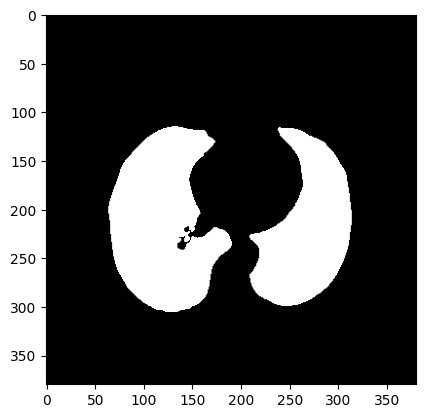

In [106]:
a = segment_lung_mask(test)
plt.imshow(a[140, :, :], cmap="gray")

In [107]:
result = []

for img, thresh_img in zip(test, a):
    row_size = img.shape[0]
    col_size = img.shape[1]

    mean = np.mean(img)
    std = np.std(img)
    img = img - mean
    img = img / std
    
    # Find the average pixel value near the lungs
    # to renormalize washed out images
    middle = img[int(col_size / 5):int(col_size / 5 * 4), int(row_size / 5):int(row_size / 5 * 4)]
    mean = np.mean(middle)
    max = np.max(img)
    min = np.min(img)
    # To improve threshold finding, I'm moving the
    # underflow and overflow on the pixel spectrum
    img[img == max] = mean
    img[img == min] = mean
    
    # apply median filter
    img = median_filter(img,size=3)
    #apply anistropic non-linear diffusion filter- This removes noise without blurring the nodule boundary
    img = anisotropic_diffusion(img)
    
    #
    # Using Kmeans to separate foreground (soft tissue / bone) and background (lung/air)
    #
    # kmeans = KMeans(n_clusters=2).fit(np.reshape(middle, [np.prod(middle.shape), 1]))
    # centers = sorted(kmeans.cluster_centers_.flatten())
    # threshold = np.mean(centers)
    # thresh_img = np.where(img < threshold, 1.0, 0.0)  # threshold the image

    # First erode away the finer elements, then dilate to include some of the pixels surrounding the lung.
    # We don't want to accidentally clip the lung.

    eroded = morphology.erosion(thresh_img, np.ones([3, 3]))
    dilation = morphology.dilation(eroded, np.ones([8, 8]))

    labels = measure.label(dilation)  # Different labels are displayed in different colors
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2] - B[0] < row_size / 20 * 19 and B[3] - B[1] < col_size / 20 * 19 and B[0] > row_size / 10 and B[
            2] < col_size / 10 * 9:
            good_labels.append(prop.label)
    mask = np.ndarray([row_size, col_size], dtype=np.int8)
    mask[:] = 0

    #
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask
    #
    for N in good_labels:
        mask = mask + np.where(labels == N, 1, 0)
    mask = morphology.dilation(mask, np.ones([10, 10]))  # one last dilation
    
    result.append(mask * img) # , mask: Lung Image, Mask
print(len(result))

320


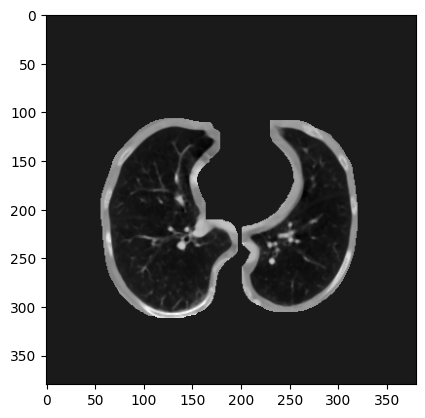

In [109]:
plt.imshow(result[140], cmap="gray")

In [111]:
numpy_to_gif(final, case_name="12_lung_v2_new", folder_name="test")

/data/hpc/dqm/3D-SegClass-Medical/assets/test/12_lung_v2_new_x.gif
